# 03 - Visualizing Distributions & Churn by Category

**Goal for today:** turn the numbers from last session into pictures, and start
answering the real question - which features actually seem to relate to churn?

**Why this matters for MLA-C01 (Domain 1 & Domain 2):**
Visual EDA is how you form hypotheses about which features will be useful before you
train anything - this is Domain 1 (Data Preparation). It also sets up Domain 2
(Model Development), since understanding which features separate the two classes well
informs your choice of algorithm and which features to prioritize or engineer further.
On AWS, this kind of visual exploration is exactly what **SageMaker Studio notebooks**
or **SageMaker Canvas** are built to support interactively.

## Step 0: Reload and re-apply last session's fix

**What this cell does:** same reload as always, plus we immediately re-apply the
`TotalCharges` fix from notebook 02. Notice this fix does NOT persist anywhere - each
notebook is independent, so any cleaning step has to be re-run every time you start a
new notebook against the raw CSV. (Later, we'll build a proper pipeline in `src/` so
we stop repeating this step by hand - but for now, repetition is fine while we're
still exploring.)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.shape

Matplotlib is building the font cache; this may take a moment.


(7043, 21)

## Step 1: Visualize the skew we found last time

**What this cell does:** `plt.subplots(1, 3, figsize=(15, 4))` creates one figure
containing 3 side-by-side plot areas (`axes`). We then loop through our three numeric
columns and draw a **histogram** for each one - a histogram groups values into bins
and shows how many rows fall into each bin, which is the standard way to see a
distribution's shape at a glance.

Watch `TotalCharges` in particular - this is the skew we spotted numerically last
session (mean far above median), now made visually obvious.

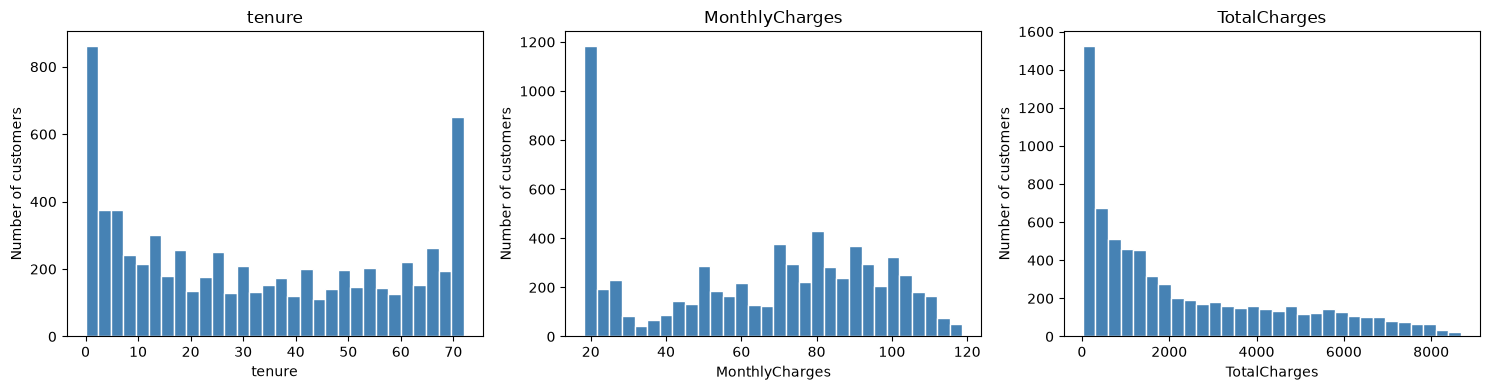

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Number of customers')

plt.tight_layout()
plt.show()

Note the `.dropna()` on `df[col]` - histograms can't plot missing values, so we drop
the 11 `NaN` rows in `TotalCharges` just for this plot. We are NOT modifying `df`
itself, only what gets passed into `.hist()` for this one chart.

You should see `TotalCharges` piled up heavily on the left with a long tail stretching
right - the visual signature of the right-skew we calculated last time. `tenure`, by
contrast, should look much flatter/more spread out - consistent with its mean and
median being close together.

## Step 2: Does contract length affect churn?

**What this cell does:** `df.groupby('Contract')` splits the DataFrame into groups,
one per unique `Contract` value (Month-to-month, One year, Two year).
`['Churn'].value_counts(normalize=True)` then computes the Yes/No proportion *within
each group separately*. `.unstack()` reshapes the result from a tall list into a wide
table (contract types as rows, Yes/No as columns) so it's easier to read.

This directly answers a real business question: **are customers on longer contracts
less likely to leave?**

In [3]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Look closely at the `Yes` column across the three rows. If you're seeing a big gap
between Month-to-month and Two year customers, that's a strong signal - `Contract`
type looks like it could be one of the most predictive features in this entire
dataset. Worth remembering when we get to feature importance later.

## Step 3: Plot it

**What this cell does:** `sns.countplot()` from the seaborn library draws bars
counting how many rows fall into each combination of two categorical columns.
`x='Contract'` puts contract type on the x-axis, and `hue='Churn'` splits each bar
into two colors (Yes/No), letting you visually compare churn counts across contract
types in one chart.

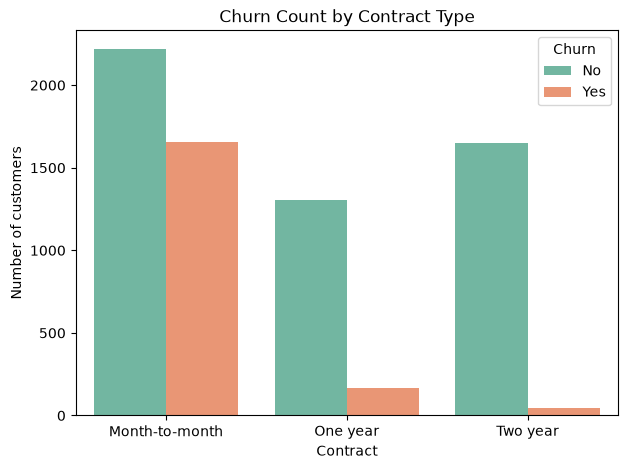

In [4]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn Count by Contract Type')
plt.ylabel('Number of customers')
plt.show()

One thing to be careful about with a plain count plot like this: it shows raw
*counts*, not *rates*. Since there are far more Month-to-month customers overall than
Two-year customers, the Month-to-month bars will look bigger regardless of churn rate.
That's exactly why we calculated the **percentage** breakdown in Step 2 first - counts
alone can be visually misleading, and the exam likes to test whether you understand
the difference between raw counts and normalized rates.

## Step 4: Does internet service type affect churn?

**What this cell does:** Same pattern as Step 2, just grouped by a different column.
Repeating the same technique on a different feature is a good habit - once you know
one groupby pattern, you can quickly test the same hypothesis against every
categorical column in the dataset.

In [5]:
churn_by_internet = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_internet

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Compare `Fiber optic` against `No` internet service. If Fiber optic customers churn
at a noticeably higher rate, that's worth flagging as something to investigate further
later - it could point to a pricing issue, a service quality issue, or just be
correlated with something else entirely (e.g. Fiber optic customers might also tend to
be on Month-to-month contracts). Correlation isn't causation - we're just gathering
candidate features here, not drawing conclusions yet.

---

**That's it for today.** Small, complete increment:
- visualized the numeric distributions (`tenure`, `MonthlyCharges`, `TotalCharges`)
  and confirmed the `TotalCharges` skew visually
- calculated and plotted churn rate broken down by `Contract` type - found a large gap
  between Month-to-month and Two-year customers
- did the same for `InternetService`
- learned the difference between raw count plots and normalized rate tables, and why
  that distinction matters

**Next session:** we'll check a few more categorical features the same way, then
start talking about feature engineering - turning these categorical columns into a
numeric format a model can actually use (one-hot encoding), before we train our first
model.